In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
from functools import partial

import numpy as np
import torch
import torch.nn as nn
from lightning.pytorch import LightningModule, LightningDataModule, Trainer, seed_everything

from src.models_cloudsat import GeoCloudSatTransformer
from src.dataloaders import GeoCloudsatDataloader

/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/william.jones/miniforge3/envs/transformer_experiments/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
import pathlib
data_path = pathlib.Path("./data/cloudsat-goes-paired/")
files = sorted(list(data_path.glob("*.nc")))
len(files)

3000

In [3]:
_ = seed_everything(42)

dl = GeoCloudsatDataloader(16, files)

Seed set to 42


In [4]:
batch = next(iter(dl.train_dataloader()))

In [5]:
input_coords, output_coords = batch[1], batch[3]

In [6]:
input_coords.shape

torch.Size([16, 2, 256, 256])

In [7]:
output_coords.shape

torch.Size([16, 2, 256])

In [8]:
model = GeoCloudSatTransformer(
    in_chans=16,
    img_size=256, 
    patch_size=16, 
    embed_dim=512, 
    depth=8,
    num_heads=8,
    decoder_embed_dim=512,
    decoder_depth=8, 
    decoder_num_heads=8,
    mlp_ratio=4.,
    num_coords=2,
    coord_limits=[
        [1  / (2*np.pi), 360 / (2*np.pi)], # longitude 1->360 degrees
        [1  / (2*np.pi), 360 / (2*np.pi)], # latitude 1->360 degrees
    ],
)

In [9]:
model

GeoCloudSatTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(16, 512, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (encoder_rope): GeoRotaryEmbedding()
  (blocks): ModuleList(
    (0-7): 8 x Block(
      (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (attn): GeoRoPEAttention(
        (qkv): Linear(in_features=512, out_features=1536, bias=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=512, out_features=512, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
        (rope): GeoRotaryEmbedding()
        (q_norm): RMSNorm((64,), eps=1e-06, elementwise_affine=True)
        (k_norm): RMSNorm((64,), eps=1e-06, elementwise_affine=True)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=512, out_features=2048, bias=True)
        (act): GELU(approximate='none')
        (drop1): 

In [10]:
input_coords.shape

torch.Size([16, 2, 256, 256])

In [11]:
mean_coords = model.mean_coords(input_coords.reshape(*input_coords.shape[:2], -1))

In [12]:
mean_coords.shape

torch.Size([16, 2])

In [13]:
coords = model.patchify_coords(input_coords, mean_coords=mean_coords)

In [14]:
rel_output_coords = output_coords - mean_coords.unsqueeze(-1)

In [15]:
B, C = mean_coords.shape

In [16]:
coords = torch.cat([torch.zeros(B, C, 1, dtype=coords.dtype, device=coords.device) ,coords, rel_output_coords], dim=-1)

In [17]:
coords.shape

torch.Size([16, 2, 513])

In [18]:
B, C, L = coords.shape

In [19]:
coords_dist = ((coords.unsqueeze(-1)-coords.unsqueeze(-2))**2).sum(1)

In [20]:
coords_dist.shape

torch.Size([16, 513, 513])

In [21]:
attn_mask = torch.zeros_like(coords_dist, dtype=torch.bool)

In [22]:
# Set class tokens to True for all
attn_mask[:,0] = True
attn_mask[:,:,0] = True

In [23]:
coords_dist[:,1:,1:257]

tensor([[[ 0.0000,  0.1709,  0.6781,  ..., 38.8600, 42.2130, 45.8525],
         [ 0.1709,  0.0000,  0.1682,  ..., 35.6487, 38.6766, 41.9929],
         [ 0.6781,  0.1682,  0.0000,  ..., 32.8003, 35.5056, 38.5015],
         ...,
         [ 8.8411,  6.7386,  4.9907,  ..., 14.5571, 15.7522, 17.2471],
         [ 8.8086,  6.7078,  4.9614,  ..., 14.6319, 15.8284, 17.3248],
         [ 8.7764,  6.6771,  4.9323,  ..., 14.7068, 15.9048, 17.4027]],

        [[ 0.0000,  0.1032,  0.4118,  ..., 36.1697, 38.6488, 41.3328],
         [ 0.1032,  0.0000,  0.1026,  ..., 33.9229, 36.1935, 38.6696],
         [ 0.4118,  0.1026,  0.0000,  ..., 31.8876, 33.9503, 36.2190],
         ...,
         [ 5.2172,  4.0627,  3.1170,  ..., 15.8277, 17.0366, 18.4532],
         [ 5.1864,  4.0332,  3.0888,  ..., 15.9046, 17.1148, 18.5328],
         [ 5.1558,  4.0039,  3.0609,  ..., 15.9817, 17.1933, 18.6126]],

        [[ 0.0000,  0.1432,  0.5697,  ..., 37.6464, 40.4006, 43.4286],
         [ 0.1432,  0.0000,  0.1416,  ..., 35

In [24]:
_, idx_input_mask = torch.sort(coords_dist[:,1:,1:257], dim=-1)

In [25]:
max_dist = torch.take_along_dim(coords_dist[:,1:,1:257], idx_input_mask[...,31:32], dim=-1)

In [26]:
attn_mask[:,1:,1:257] = coords_dist[:,1:,1:257] <= max_dist

In [27]:
_, idx_output_mask = torch.sort(coords_dist[:,1:,257:], dim=-1)
max_dist = torch.take_along_dim(coords_dist[:,1:,257:], idx_output_mask[...,31:32], dim=-1)
attn_mask[:,1:,257:] = coords_dist[:,1:,257:] <= max_dist

In [28]:
attn_mask

tensor([[[ True,  True,  True,  ...,  True,  True,  True],
         [ True,  True,  True,  ...,  True,  True,  True],
         [ True,  True,  True,  ...,  True,  True,  True],
         ...,
         [ True, False, False,  ...,  True,  True,  True],
         [ True, False, False,  ...,  True,  True,  True],
         [ True, False, False,  ...,  True,  True,  True]],

        [[ True,  True,  True,  ...,  True,  True,  True],
         [ True,  True,  True,  ...,  True,  True,  True],
         [ True,  True,  True,  ...,  True,  True,  True],
         ...,
         [ True, False, False,  ...,  True,  True,  True],
         [ True, False, False,  ...,  True,  True,  True],
         [ True, False, False,  ...,  True,  True,  True]],

        [[ True,  True,  True,  ...,  True,  True,  True],
         [ True,  True,  True,  ...,  True,  True,  True],
         [ True,  True,  True,  ...,  True,  True,  True],
         ...,
         [ True, False, False,  ...,  True,  True,  True],
         [

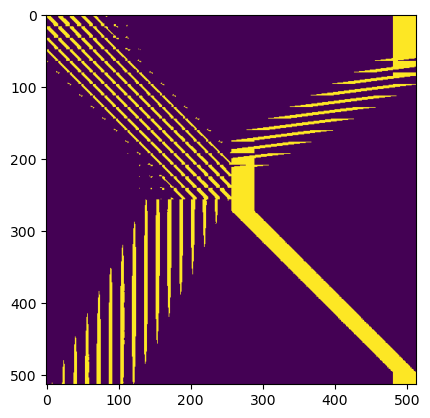

In [29]:
import matplotlib.pyplot as plt
plt.imshow(attn_mask[0].detach().numpy())

In [30]:
input_coords[0].mean((1,2))

tensor([-108.6365,  -14.9636])

In [31]:
output_coords[0].mean(1)

tensor([-108.0979,  -14.9570])

In [32]:
mean_coords

tensor([[-108.6365,  -14.9636],
        [ -88.2374,  -19.1272],
        [-100.2515,  -23.9536],
        [ -93.4928,   22.5225],
        [ -80.2746,  -21.0331],
        [ -86.4073,  -21.7007],
        [ -91.9550,  -39.3388],
        [ -31.3423,  -14.8255],
        [ -82.0065,   11.5237],
        [ -66.4613,    7.7402],
        [ -82.4044,   35.9286],
        [-113.3108,   -9.4963],
        [ -44.9583,   17.7405],
        [ -77.2353,  -14.9540],
        [ -38.4661,   -9.7146],
        [ -80.0431,   25.5937]])

In [33]:
model.mean_coords(input_coords.reshape(*input_coords.shape[:2], -1))[0]

tensor([-108.6365,  -14.9636])

In [34]:
model.coord_limits

[[0.15915494309189535, 57.29577951308232],
 [0.15915494309189535, 57.29577951308232]]

In [35]:
360/57.29577951308232

6.283185307179586

In [36]:
2*np.pi

6.283185307179586

In [37]:
attn_mask.sum(-1)

tensor([[513,  65,  65,  ...,  65,  65,  65],
        [513,  65,  65,  ...,  65,  65,  65],
        [513,  65,  65,  ...,  65,  65,  65],
        ...,
        [513,  65,  65,  ...,  65,  65,  65],
        [513,  65,  65,  ...,  65,  65,  65],
        [513,  65,  65,  ...,  65,  65,  65]])

In [41]:
model.blocks[0].attn

GeoRoPEAttention(
  (qkv): Linear(in_features=512, out_features=1536, bias=False)
  (attn_drop): Dropout(p=0.0, inplace=False)
  (proj): Linear(in_features=512, out_features=512, bias=True)
  (proj_drop): Dropout(p=0.0, inplace=False)
  (rope): GeoRotaryEmbedding()
  (q_norm): RMSNorm((64,), eps=1e-06, elementwise_affine=True)
  (k_norm): RMSNorm((64,), eps=1e-06, elementwise_affine=True)
)

In [45]:
x = torch.rand(1,512,512)

In [50]:
B, N, C = x.shape

In [46]:
attn = model.blocks[0].attn

In [78]:
qkv = attn.qkv(x)

In [79]:
qkv.shape

torch.Size([1, 512, 1536])

In [51]:
qkv = qkv.reshape(B, N, 3, 8, -1).permute(2, 0, 3, 1, 4)

In [52]:
qkv.shape

torch.Size([3, 1, 8, 512, 64])

In [53]:
q, k, v = qkv.unbind(0)

In [55]:
%timeit torch.nn.functional.scaled_dot_product_attention(q, k, v)

413 μs ± 20.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [58]:
def scaled_dot_product_attention(query, key, value, attn_mask=None, dropout_p=0.0,
        is_causal=False, scale=None, enable_gqa=False) -> torch.Tensor:
    L, S = query.size(-2), key.size(-2)
    scale_factor = 1 / (query.size(-1))**0.5 if scale is None else scale
    attn_bias = torch.zeros(L, S, dtype=query.dtype, device=query.device)
    if is_causal:
        assert attn_mask is None
        temp_mask = torch.ones(L, S, dtype=torch.bool).tril(diagonal=0)
        attn_bias.masked_fill_(temp_mask.logical_not(), float("-inf"))

    if attn_mask is not None:
        if attn_mask.dtype == torch.bool:
            attn_bias.masked_fill_(attn_mask.logical_not(), float("-inf"))
        else:
            attn_bias = attn_mask + attn_bias

    if enable_gqa:
        key = key.repeat_interleave(query.size(-3)//key.size(-3), -3)
        value = value.repeat_interleave(query.size(-3)//value.size(-3), -3)

    attn_weight = query @ key.transpose(-2, -1) * scale_factor
    attn_weight += attn_bias
    attn_weight = torch.softmax(attn_weight, dim=-1)
    attn_weight = torch.dropout(attn_weight, dropout_p, train=True)
    return attn_weight @ value


In [60]:
%timeit scaled_dot_product_attention(q, k, v)

2.03 ms ± 58.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [61]:
attn_mask.shape

torch.Size([16, 513, 513])

In [64]:
mask = attn_mask[:1, 1:, 1:]

In [66]:
torch.where(mask)[-1].shape

torch.Size([32768])

In [74]:
attn_idx = torch.cat([
    torch.sort(coords_dist[:,1:,1:257], dim=-1)[1][...,:32],
    torch.sort(coords_dist[:,1:,257:], dim=-1)[1][...,:32]+256,
], dim=-1)[:1].unsqueeze(1)

In [71]:
attn_idx.shape

torch.Size([1, 512, 64])

In [73]:
k.shape

torch.Size([1, 8, 512, 64])

In [83]:
torch.take_along_dim(k.unsqueeze(-1), attn_idx.unsqueeze(-2), dim=2).shape

torch.Size([1, 8, 512, 64, 64])

In [87]:
attn_weight = (q.unsqueeze(-1) * torch.take_along_dim(k.unsqueeze(-1), attn_idx.unsqueeze(-2), dim=2)).sum(-1)

In [112]:
torch.take_along_dim(k.unsqueeze(-1), attn_idx.unsqueeze(-2), dim=2).shape

torch.Size([1, 8, 512, 64, 64])

In [114]:
q.shape

torch.Size([1, 8, 512, 64])

In [88]:
attn_weight.shape

torch.Size([1, 8, 512, 64])

In [91]:
torch.softmax(attn_weight, dim=-1).shape

torch.Size([1, 8, 512, 64])

In [92]:
v.shape

torch.Size([1, 8, 512, 64])

In [93]:
q.size(-1)

64

In [100]:
torch.softmax(attn_weight / 8, dim=-1).shape

torch.Size([1, 8, 512, 64])

In [101]:
v.shape

torch.Size([1, 8, 512, 64])

In [98]:
(torch.softmax((q @ k.transpose(-2,-1)) / 8, dim=-1) @ v).shape

torch.Size([1, 8, 512, 64])

In [104]:
(torch.softmax(attn_weight / 8, dim=-1).unsqueeze(-1) * v.unsqueeze(-2)).sum(-1).shape

torch.Size([1, 8, 512, 64])

In [110]:
def indexed_dot_product_attention(q, k, v, attn_idx, dropout_p=0.0) -> torch.Tensor:
    L, S = q.size(-2), k.size(-2)
    scale_factor = 1 / (q.size(-1))**0.5

    attn_weight = (q.unsqueeze(-1) * torch.take_along_dim(k.unsqueeze(-1), attn_idx.unsqueeze(-2), dim=2)).sum(-1) * scale_factor
    attn_weight = torch.softmax(attn_weight, dim=-1)
    attn_weight = torch.dropout(attn_weight, dropout_p, train=True)
    return (attn_weight.unsqueeze(-1) * v.unsqueeze(-2)).sum(-1)


In [111]:
%timeit indexed_dot_product_attention(q, k, v, attn_idx)

16.8 ms ± 115 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
